In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [32]:
student_name = "Brylle Edsil F. Untalasco"
student_id = "384"

In [33]:
id_num = int(student_id[-3:])

color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

print("Colors generated:", color1, color2)

Colors generated: #808080 #008000


In [15]:
import pandas as pd

# Load dataset (IMPORTANT: file must be in same folder as notebook)
df = pd.read_csv("spotify_top_1000_tracks.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433


In [7]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles inside folder:")
print(os.listdir())

Current folder:
c:\Users\ex012\Desktop\Activity7_DataVisualization

Files inside folder:
['.git', 'Activity7.ipynb', 'popularity_trend.gif', 'spotify_top_1000_tracks.csv']


In [16]:
# Convert release date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Extract year
df['year'] = df['release_date'].dt.year

# Remove missing values
df = df.dropna(subset=['year', 'popularity', 'duration_min'])

# Convert year to integer
df['year'] = df['year'].astype(int)

# Clean text columns
df['track_name'] = df['track_name'].str.strip()
df['artist'] = df['artist'].str.strip()

# Remove duplicates
df = df.drop_duplicates(subset=['track_name', 'artist'])

print("Data cleaned successfully!")
df.head()

Data cleaned successfully!


,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min,year
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767,2018
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883,2016
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667,2019
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083,2020
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433,2016


In [1]:
print("DATA CLEANING COMPLETE — READY FOR VISUALIZATION")

DATA CLEANING COMPLETE — READY FOR VISUALIZATION


In [17]:
if 'tempo' in df.columns:
    df['tempo_category'] = pd.cut(
        df['tempo'],
        bins=[0, 100, 140, np.inf],
        labels=['Slow', 'Medium', 'Fast']
    )

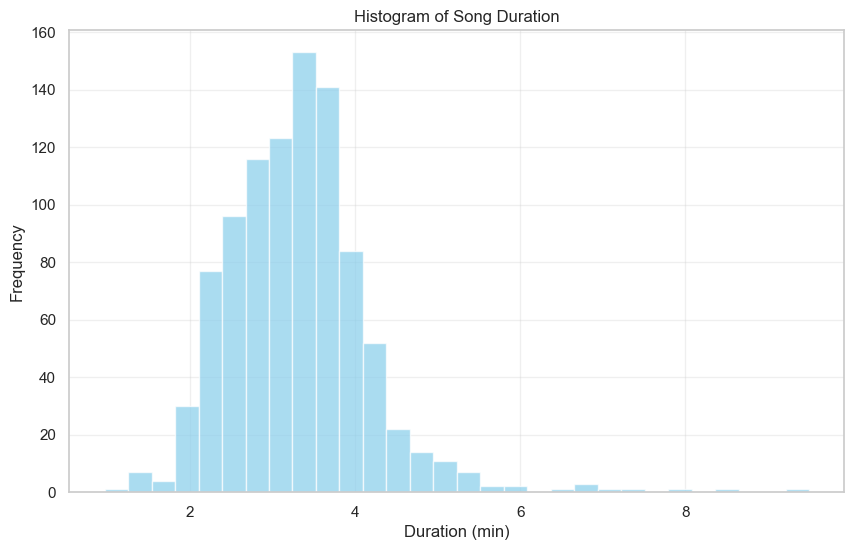

In [18]:
plt.figure(figsize=(10,6))

plt.hist(df['duration_min'], bins=30, color='skyblue', alpha=0.7)

plt.title("Histogram of Song Duration")
plt.xlabel("Duration (min)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.show()

C:\Users\ex012\AppData\Local\Temp\ipykernel_25572\1378650970.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


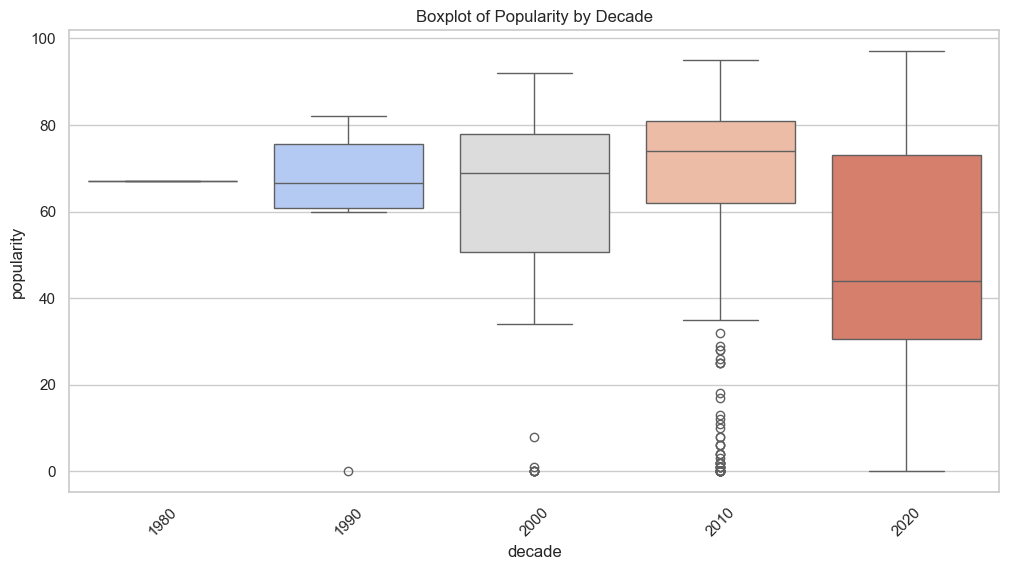

In [9]:
# Create decade column
df['decade'] = (df['year'] // 10) * 10

plt.figure(figsize=(12,6))

sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')

plt.title("Boxplot of Popularity by Decade")
plt.xticks(rotation=45)

plt.show()

C:\Users\ex012\AppData\Local\Temp\ipykernel_25572\50665120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


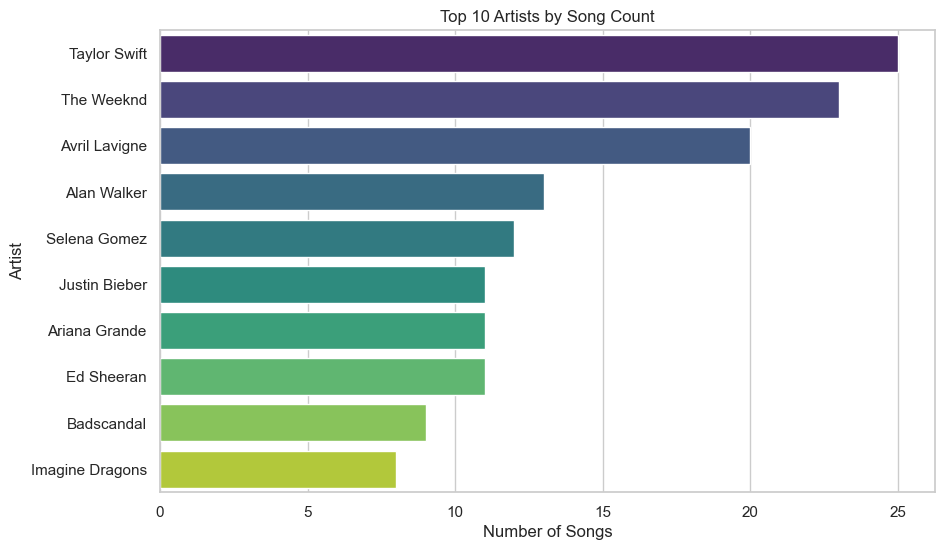

In [10]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='artist',
    data=df,
    order=df['artist'].value_counts().head(10).index,
    palette='viridis'
)

plt.title("Top 10 Artists by Song Count")
plt.xlabel("Number of Songs")
plt.ylabel("Artist")

plt.show()

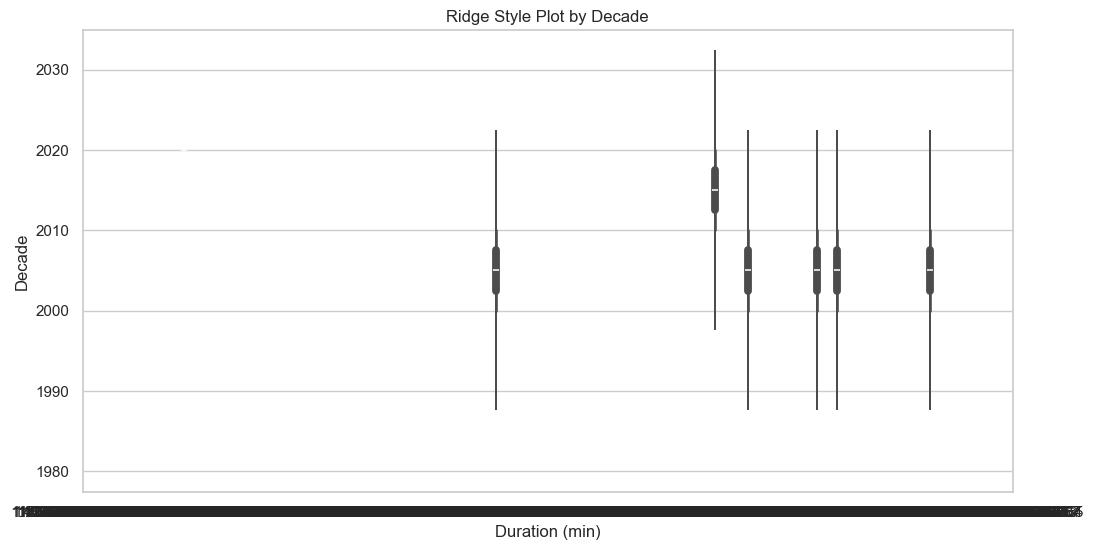

In [12]:
# Ensure decade exists safely
df['decade'] = (df['year'] // 10) * 10

# Clean needed columns
df_clean = df.dropna(subset=['duration_min', 'decade'])

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_clean,
    x='duration_min',
    y='decade'
)

plt.title("Ridge Style Plot by Decade")
plt.xlabel("Duration (min)")
plt.ylabel("Decade")

plt.show()

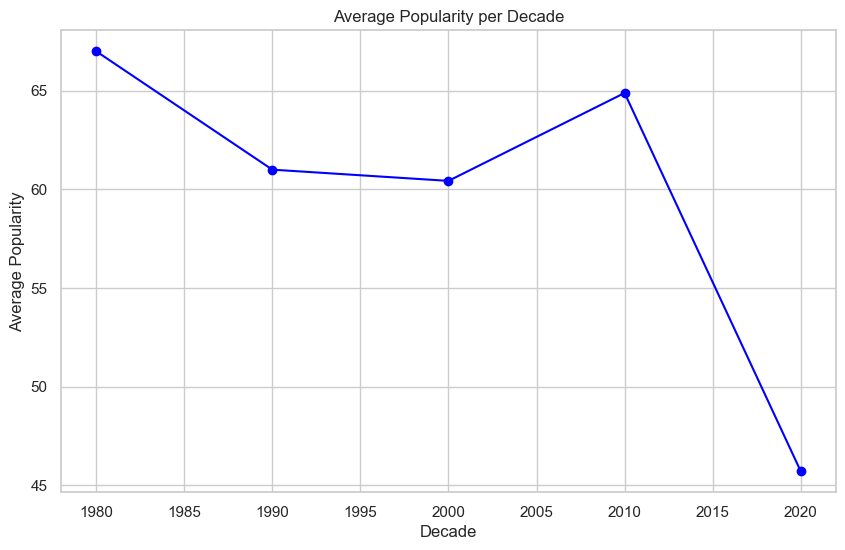

In [13]:
# Make sure decade exists
df['decade'] = (df['year'] // 10) * 10

# Compute average popularity per decade
avg_pop = df.groupby('decade')['popularity'].mean()

plt.figure(figsize=(10,6))

avg_pop.plot(kind='line', marker='o', color='blue')

plt.title("Average Popularity per Decade")
plt.xlabel("Decade")
plt.ylabel("Average Popularity")
plt.grid(True)

plt.show()

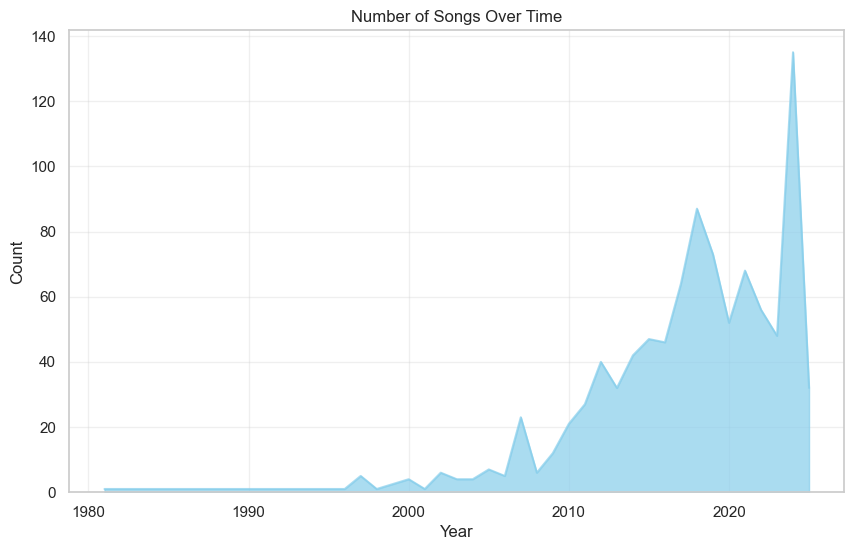

In [19]:
# Ensure year exists
df['release_year'] = df['year']

# Count songs per year
count_by_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,6))

count_by_year.plot(kind='area', color='skyblue', alpha=0.7)

plt.title("Number of Songs Over Time")
plt.xlabel("Year")
plt.ylabel("Count")

plt.grid(True, alpha=0.3)
plt.show()

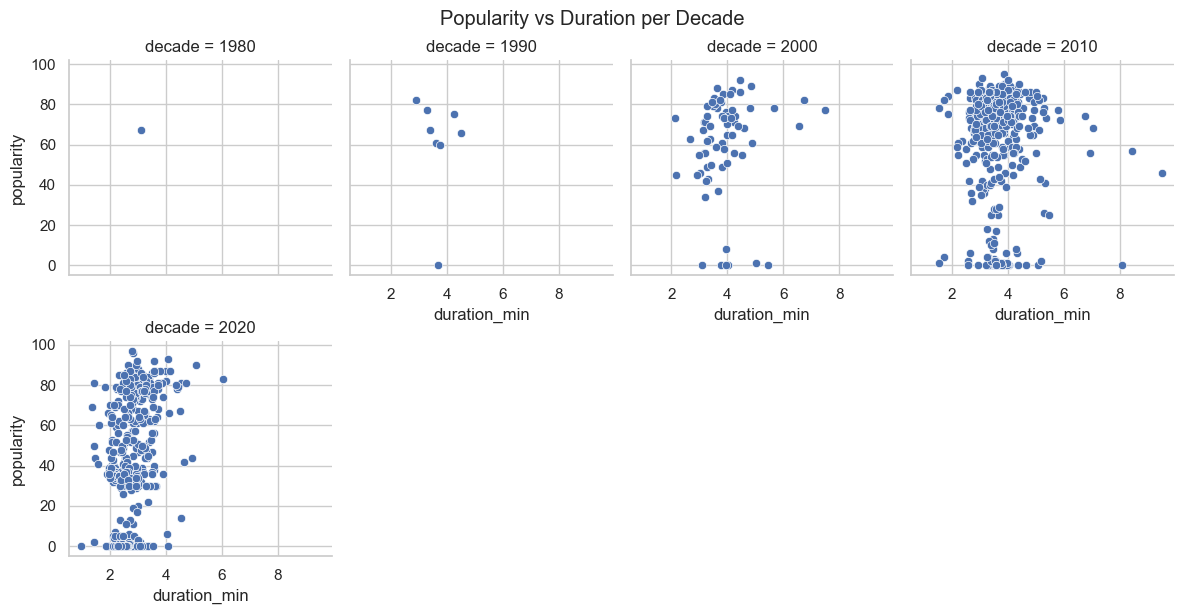

In [20]:
# Ensure decade exists
df['decade'] = (df['year'] // 10) * 10

# Create FacetGrid safely
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3)

g.map_dataframe(
    sns.scatterplot,
    x='duration_min',
    y='popularity'
)

g.fig.suptitle("Popularity vs Duration per Decade", y=1.02)

plt.show()

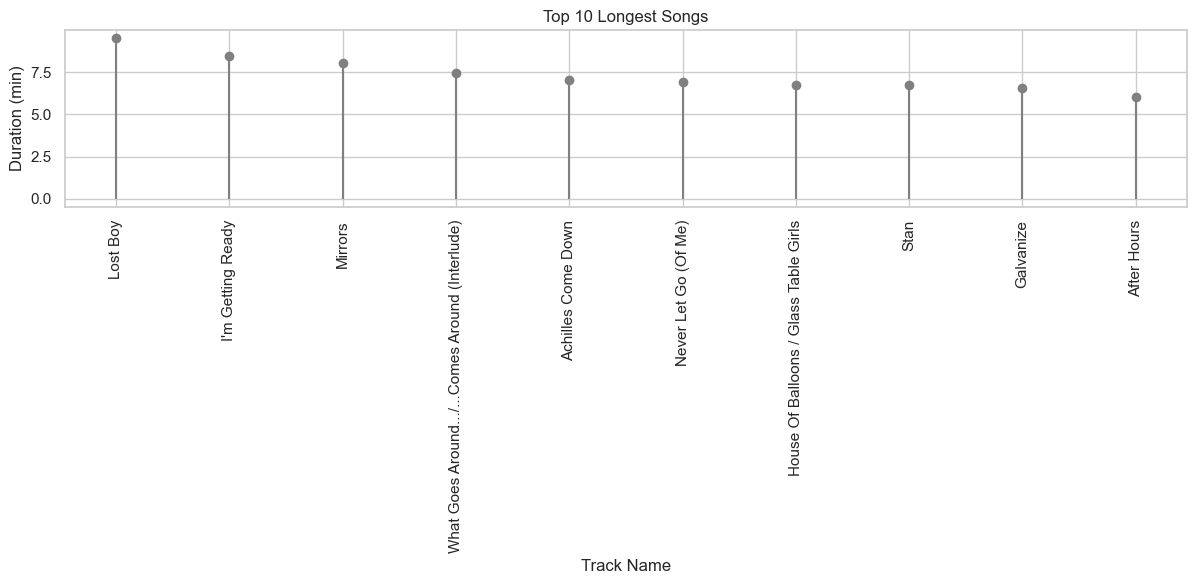

In [21]:
# Get top 10 longest tracks
longest = df.nlargest(10, 'duration_min')

plt.figure(figsize=(12,6))

plt.stem(
    longest['track_name'],
    longest['duration_min'],
    linefmt='grey',
    markerfmt='o',
    basefmt=" "
)

plt.xticks(rotation=90)

plt.title("Top 10 Longest Songs")
plt.xlabel("Track Name")
plt.ylabel("Duration (min)")

plt.tight_layout()
plt.show()

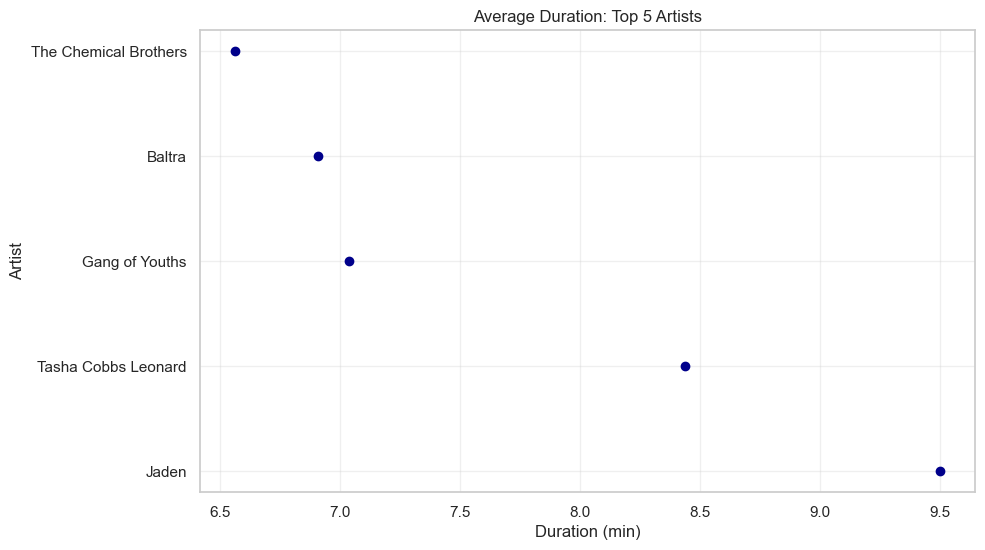

In [22]:
# Get top 5 artists by average duration
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5)

plt.figure(figsize=(10,6))

plt.plot(
    avg_duration.values,
    avg_duration.index,
    'o',
    color='darkblue'
)

plt.title("Average Duration: Top 5 Artists")
plt.xlabel("Duration (min)")
plt.ylabel("Artist")

plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x600 with 0 Axes>

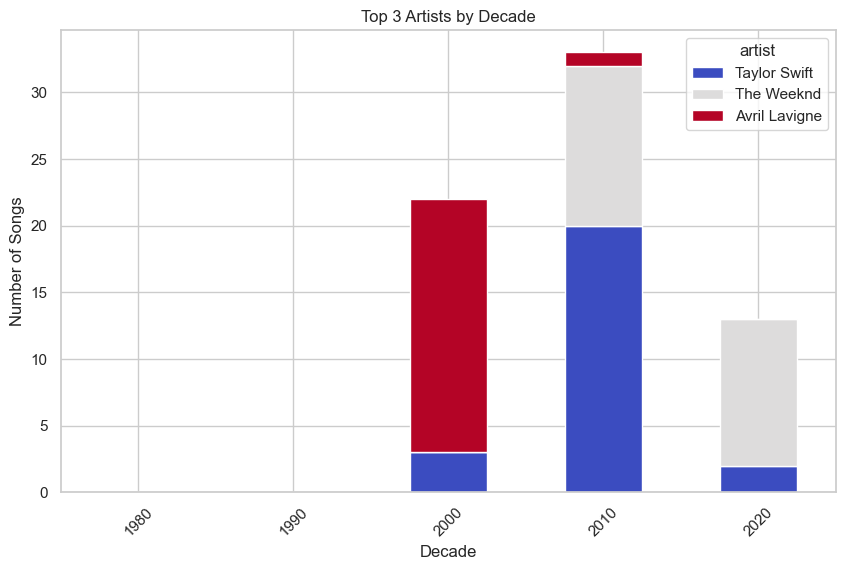

In [23]:
# Ensure decade exists
df['decade'] = (df['year'] // 10) * 10

# Create crosstab
crosstab = pd.crosstab(df['decade'], df['artist'])

# Get top 3 artists
top3 = df['artist'].value_counts().head(3).index

plt.figure(figsize=(10,6))

crosstab[top3].plot(
    kind='bar',
    stacked=True,
    colormap='coolwarm',
    figsize=(10,6)
)

plt.title("Top 3 Artists by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Songs")

plt.xticks(rotation=45)
plt.show()

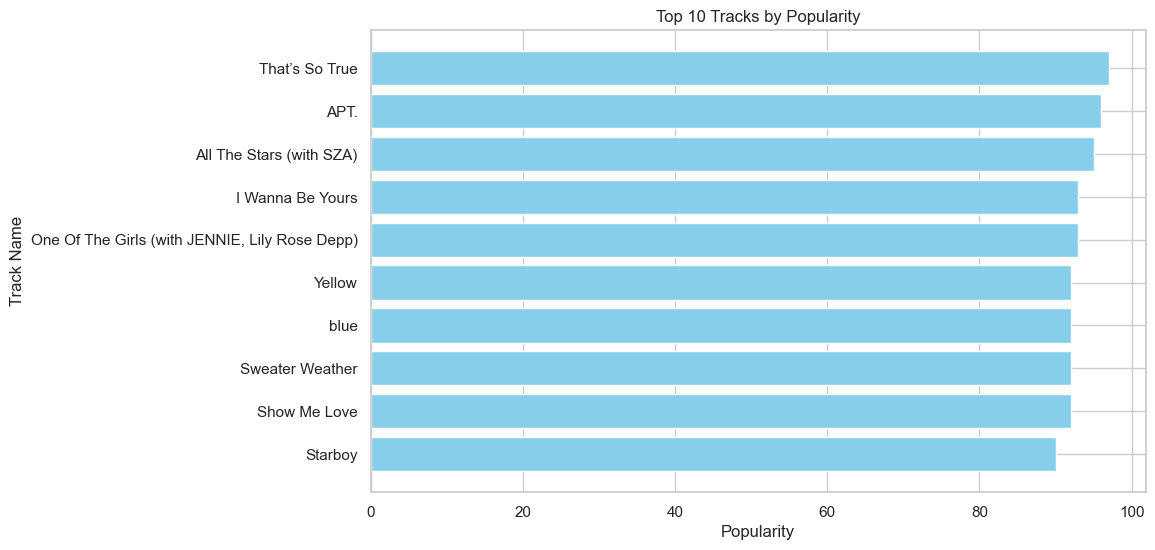

In [24]:
# Get top 10 most popular tracks
top_tracks = df.nlargest(10, 'popularity')

plt.figure(figsize=(10,6))

plt.barh(
    top_tracks['track_name'],
    top_tracks['popularity'],
    color='skyblue'
)

plt.title("Top 10 Tracks by Popularity")
plt.xlabel("Popularity")
plt.ylabel("Track Name")

plt.gca().invert_yaxis()  # highest on top

plt.show()

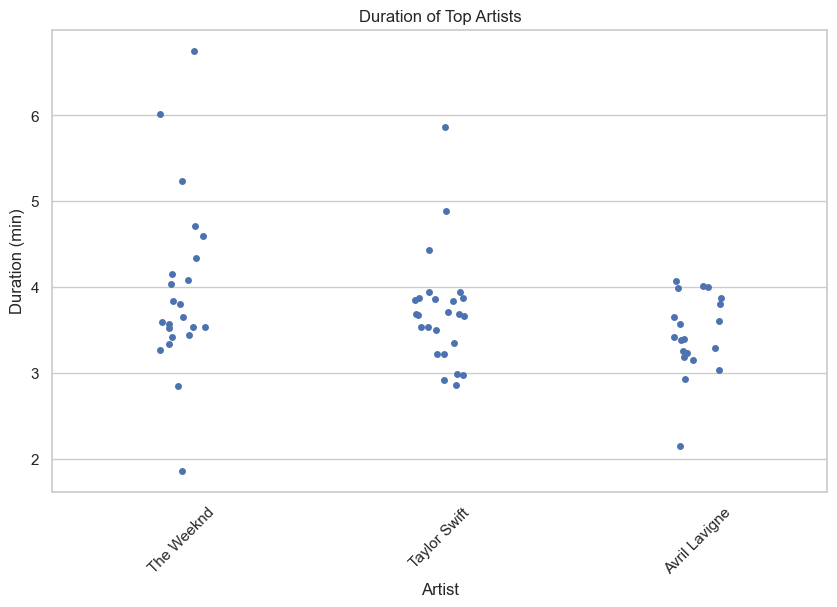

In [25]:
# Get top 3 artists
top_artists = df['artist'].value_counts().head(3).index

plt.figure(figsize=(10,6))

sns.stripplot(
    data=df[df['artist'].isin(top_artists)],
    x='artist',
    y='duration_min',
    jitter=True
)

plt.title("Duration of Top Artists")
plt.xlabel("Artist")
plt.ylabel("Duration (min)")

plt.xticks(rotation=45)

plt.show()

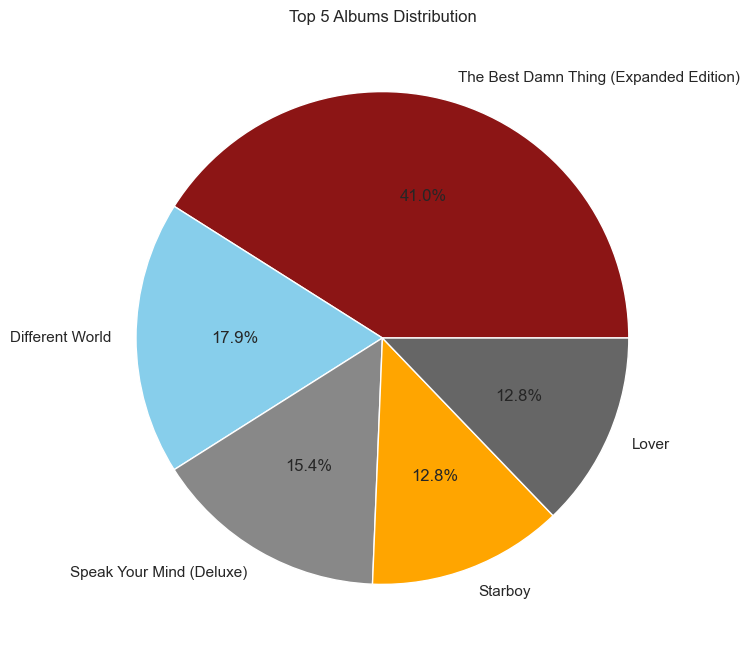

In [26]:
# Get top 5 albums
top_albums = df['album'].value_counts().head(5)

# Colors (safe mix of custom + neutral)
colors = ['#8C1515', 'skyblue', '#888888', 'orange', '#666666']

plt.figure(figsize=(8,8))

plt.pie(
    top_albums,
    labels=top_albums.index,
    autopct='%1.1f%%',
    colors=colors
)

plt.title("Top 5 Albums Distribution")

plt.show()

<Figure size 600x600 with 0 Axes>

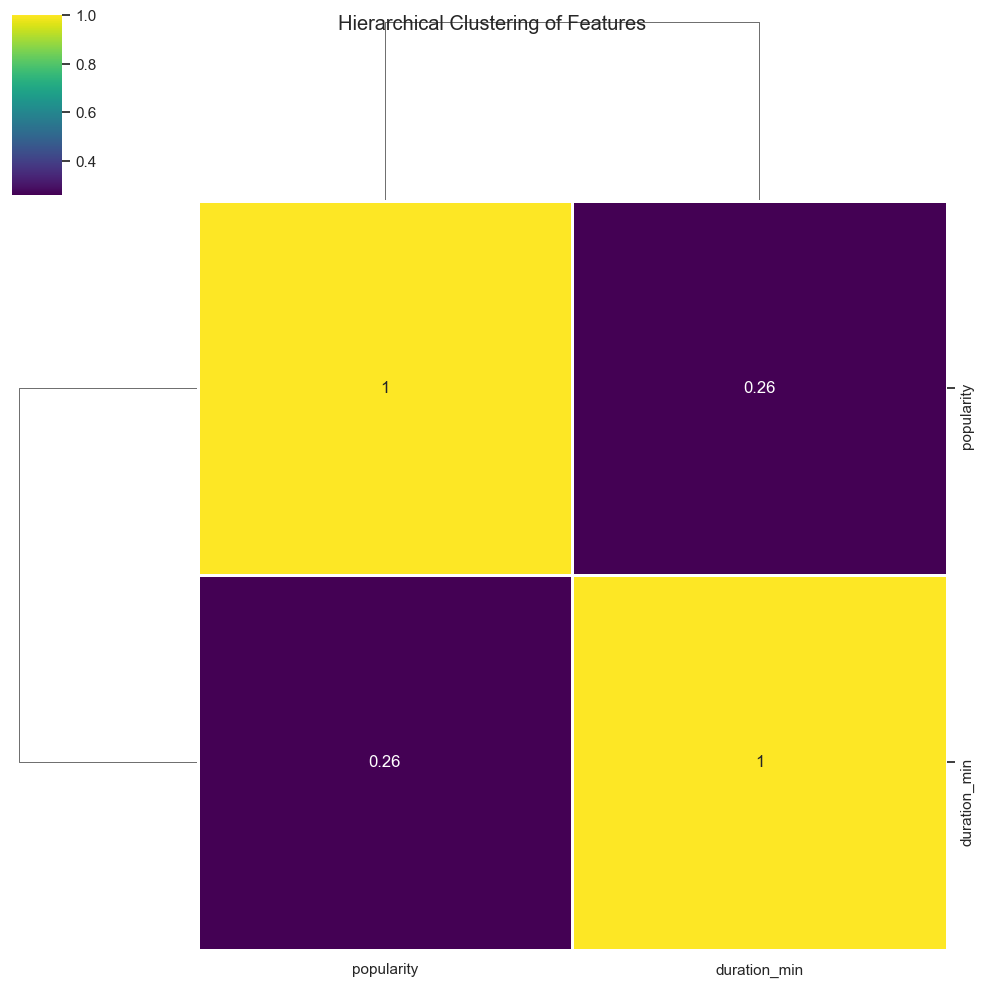

In [27]:
# Select numeric columns safely
numerical_cols = ['popularity', 'duration_min']
df_numeric = df[numerical_cols].dropna()

plt.figure(figsize=(6,6))

sns.clustermap(
    df_numeric.corr(),
    annot=True,
    cmap='viridis',
    linewidths=0.75
)

plt.suptitle("Hierarchical Clustering of Features")

plt.show()

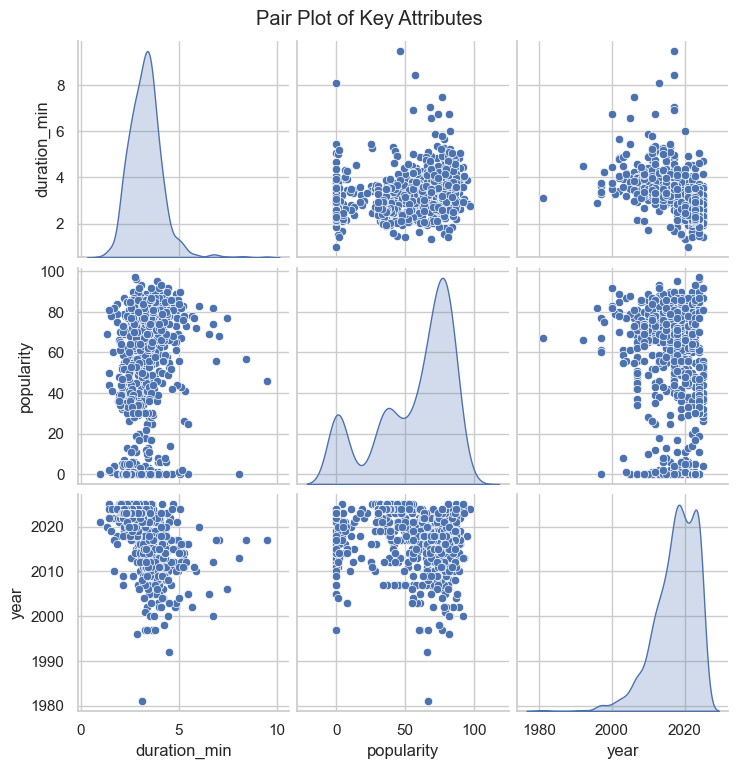

In [29]:
# Ensure required columns exist and are clean
df_pair = df[['duration_min', 'popularity', 'year']].dropna()

sns.pairplot(
    df_pair,
    diag_kind='kde'
)

plt.suptitle("Pair Plot of Key Attributes", y=1.02)

plt.show()

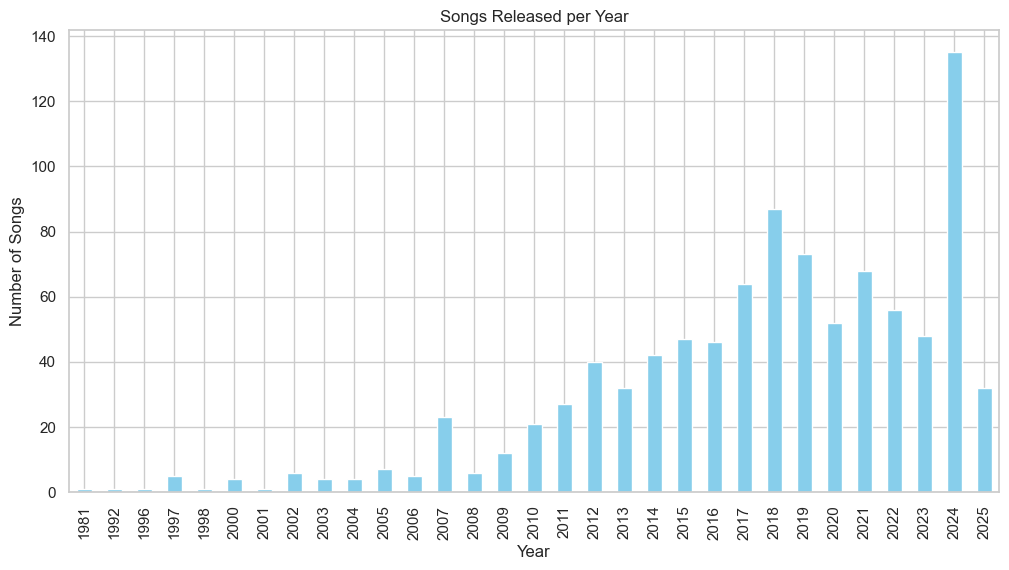

In [30]:
# Ensure year column exists
df['release_year'] = df['year']

# Count songs per year
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

year_counts.plot(
    kind='bar',
    color='skyblue'
)

plt.title("Songs Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Songs")

plt.xticks(rotation=90)

plt.show()

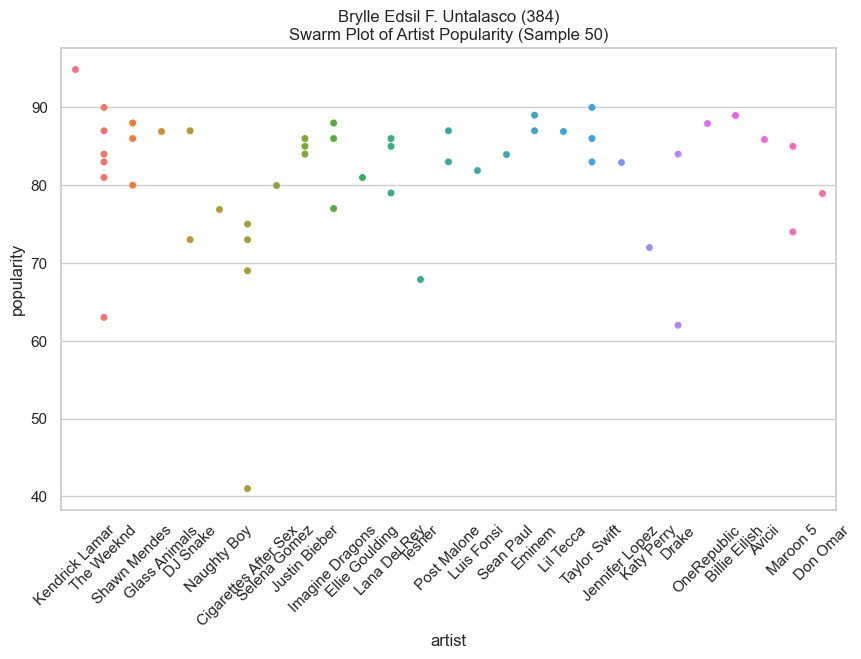

In [35]:
plt.figure(figsize=(10,6))

sns.swarmplot(
    data=df.head(50),
    x='artist',
    y='popularity',
    hue='artist',     # FIX for seaborn warning
    legend=False
)

plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)")
plt.xticks(rotation=45)

plt.show()

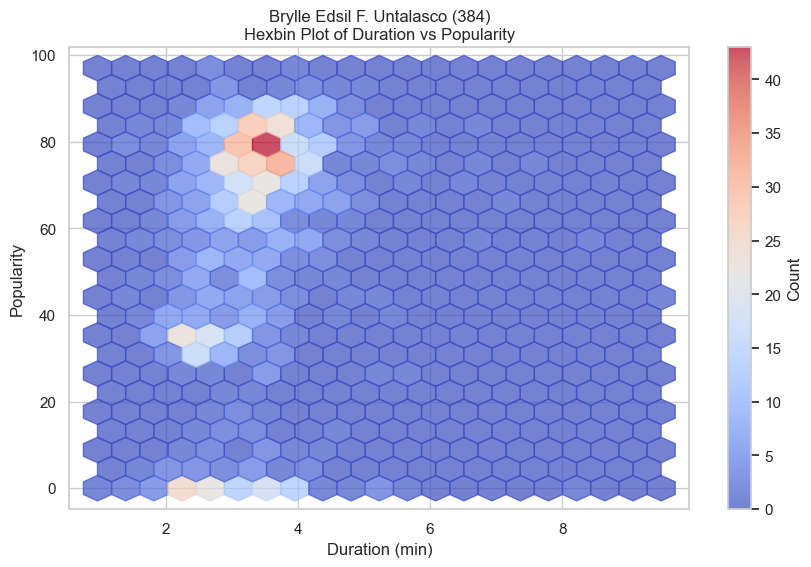

In [36]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df['duration_min'],
    df['popularity'],
    gridsize=20,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel('Duration (min)')
plt.ylabel('Popularity')
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity")

plt.colorbar(label='Count')
plt.show()

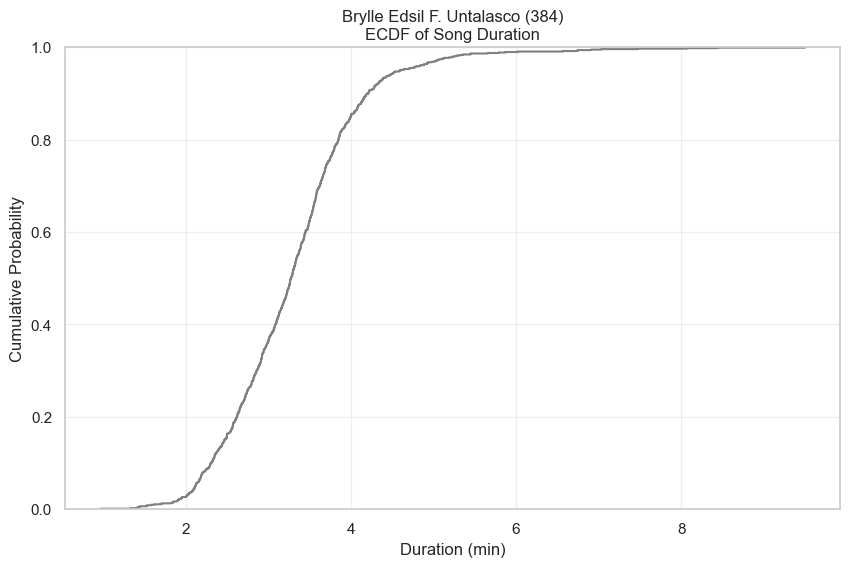

In [37]:
plt.figure(figsize=(10,6))

sns.ecdfplot(
    data=df,
    x='duration_min',
    color=color1
)

plt.title(f"{student_name} ({student_id})\nECDF of Song Duration")
plt.xlabel("Duration (min)")
plt.ylabel("Cumulative Probability")

plt.grid(True, alpha=0.3)
plt.show()

<Figure size 1000x600 with 0 Axes>

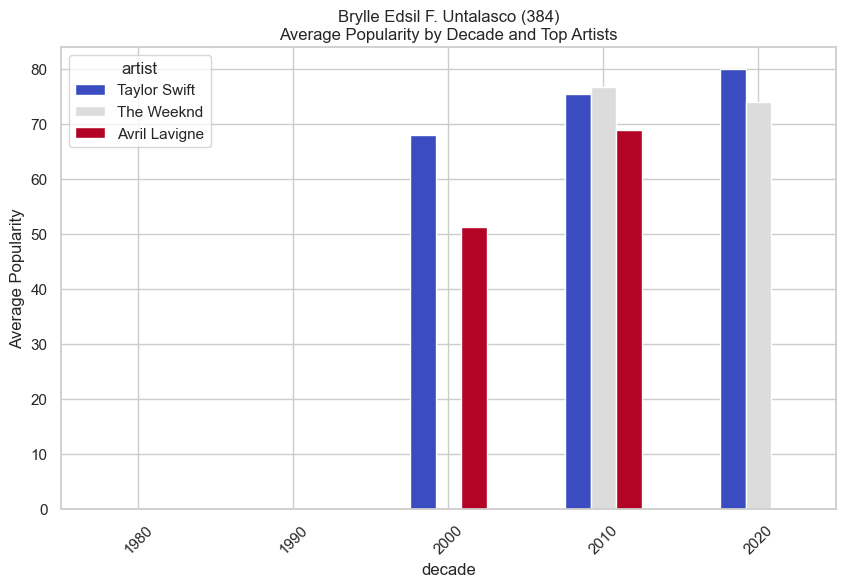

In [38]:
# Ensure decade exists
df['decade'] = (df['year'] // 10) * 10

# Get top 3 artists (safe redefinition)
top3 = df['artist'].value_counts().head(3).index

# Group data
avg_artist_decade = df.groupby(['decade', 'artist'])['popularity'].mean().unstack().fillna(0)

plt.figure(figsize=(10,6))

avg_artist_decade[top3].plot(
    kind='bar',
    figsize=(10,6),
    colormap='coolwarm'
)

plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)

plt.show()

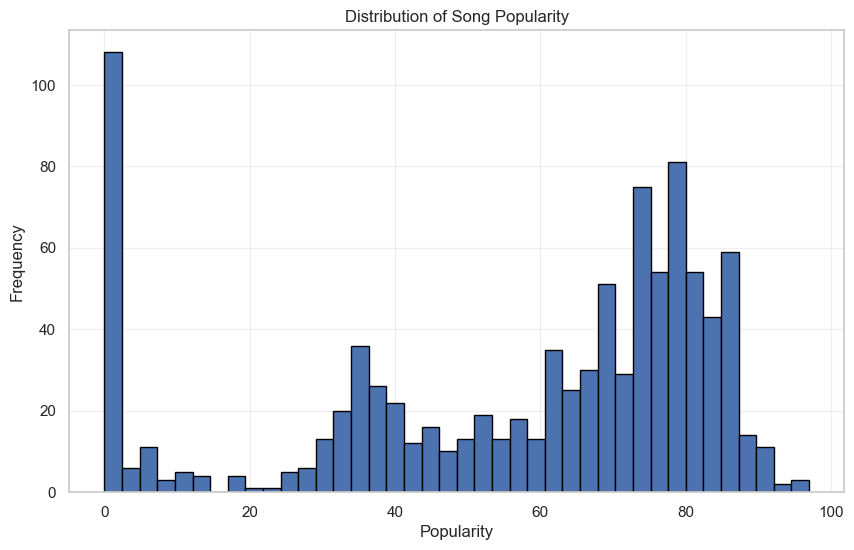

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df['popularity'], bins=40, edgecolor='black')

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.show()

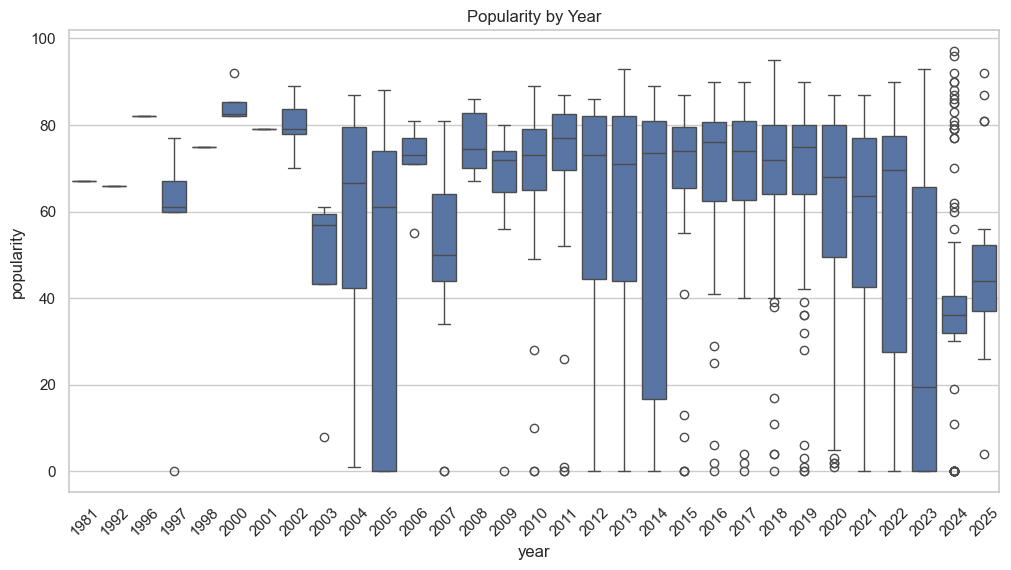

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(x='year', y='popularity', data=df)

plt.title("Popularity by Year")
plt.xticks(rotation=45)

plt.show()

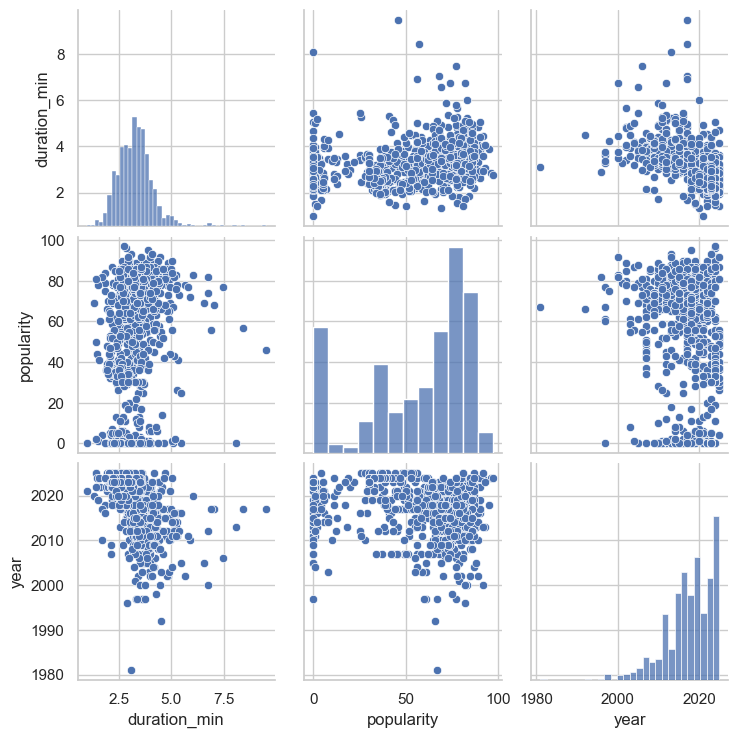

In [11]:
import seaborn as sns

sns.pairplot(df[['duration_min', 'popularity', 'year']].dropna())

plt.show()

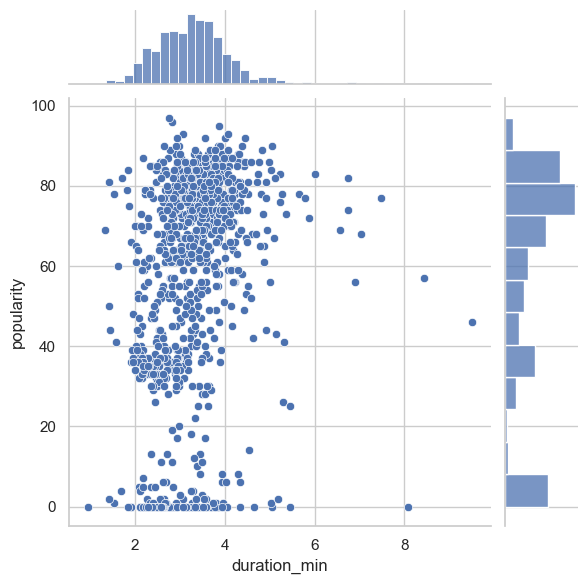

In [12]:
import seaborn as sns

sns.jointplot(x='duration_min', y='popularity', data=df, kind='scatter')

plt.show()

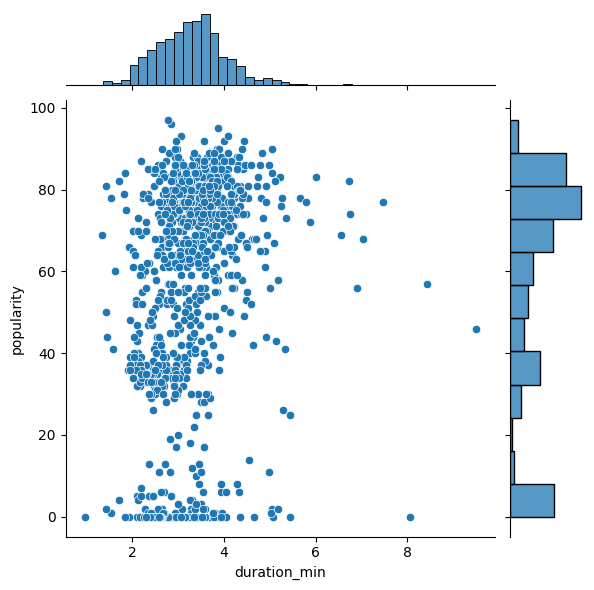

In [13]:
sns.jointplot(x='duration_min', y='popularity', data=df, kind='scatter')
plt.show()

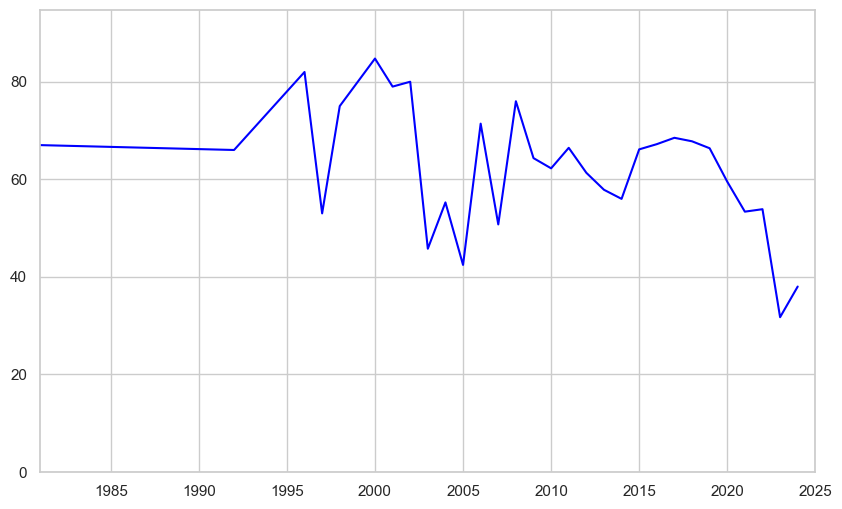

GIF saved successfully!


In [13]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Compute yearly average popularity
yearly = df.groupby('year')['popularity'].mean().reset_index()
yearly = yearly.sort_values('year')

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

ax.set_xlim(yearly['year'].min(), yearly['year'].max())
ax.set_ylim(0, yearly['popularity'].max() + 10)

line, = ax.plot([], [], color='blue')

# Update function for animation
def update(i):
    x = yearly['year'][:i]
    y = yearly['popularity'][:i]
    line.set_data(x, y)
    return line,

# Create animation
ani = FuncAnimation(fig, update, frames=len(yearly), interval=100)

# Save GIF
ani.save("popularity_trend.gif", writer=PillowWriter(fps=10))

plt.show()

print("GIF saved successfully!")

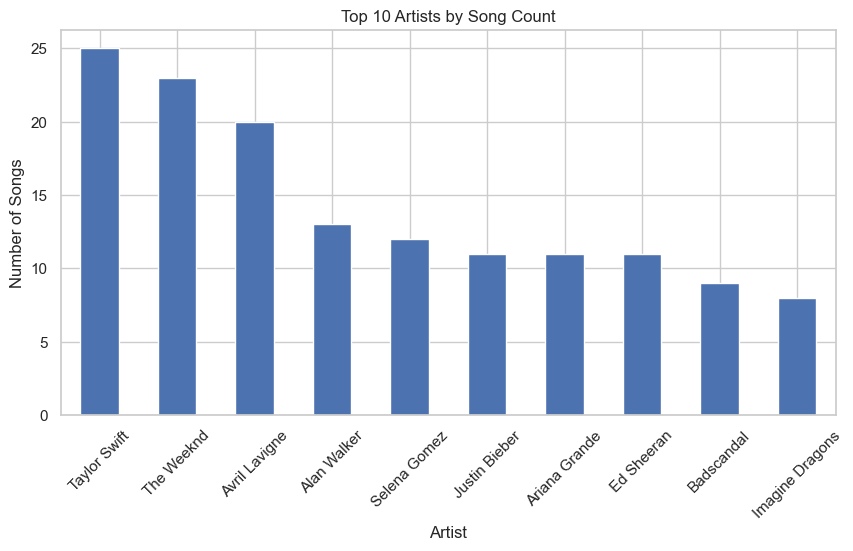

In [14]:
top_artists = df['artist'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_artists.plot(kind='bar')

plt.title("Top 10 Artists by Song Count")
plt.xlabel("Artist")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)

plt.show()

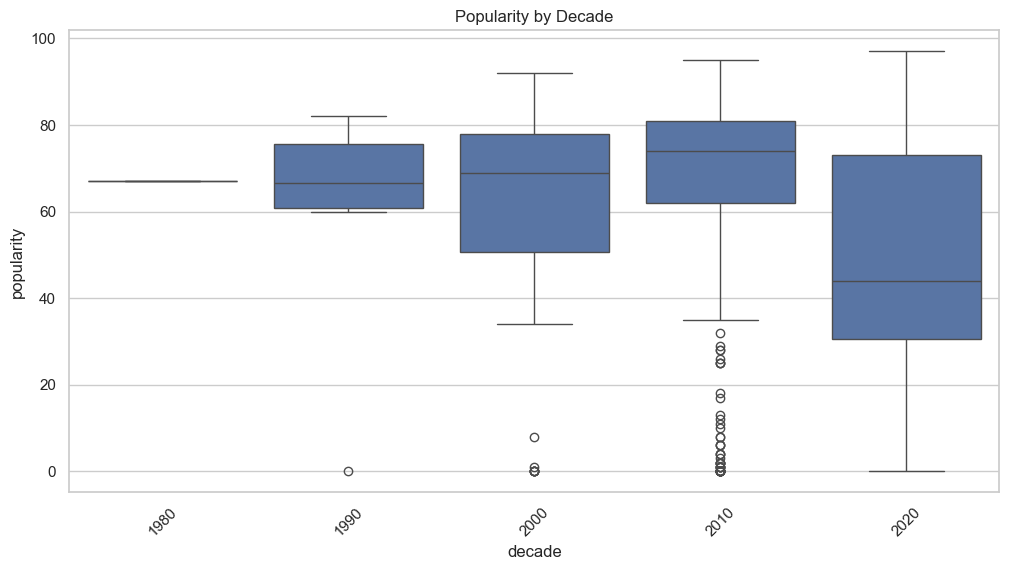

In [15]:
df['decade'] = (df['year'] // 10) * 10

plt.figure(figsize=(12,6))
sns.boxplot(x='decade', y='popularity', data=df)

plt.title("Popularity by Decade")
plt.xticks(rotation=45)

plt.show()

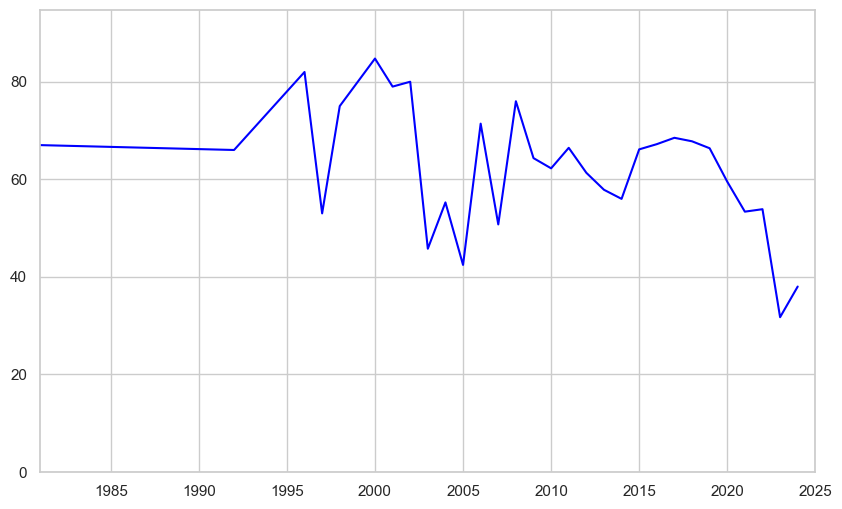

In [16]:
from matplotlib.animation import FuncAnimation, PillowWriter

yearly = df.groupby('year')['popularity'].mean().reset_index()
yearly = yearly.sort_values('year')

fig, ax = plt.subplots(figsize=(10,6))

ax.set_xlim(yearly['year'].min(), yearly['year'].max())
ax.set_ylim(0, yearly['popularity'].max() + 10)

line, = ax.plot([], [], color='blue')

def update(i):
    x = yearly['year'][:i]
    y = yearly['popularity'][:i]
    line.set_data(x, y)
    return line,

ani = FuncAnimation(fig, update, frames=len(yearly), interval=100)

ani.save("yearly_popularity_main.gif", writer=PillowWriter(fps=10))

plt.show()

In [17]:
ani.save("yearly_popularity_try_it.gif", writer=PillowWriter(fps=15))

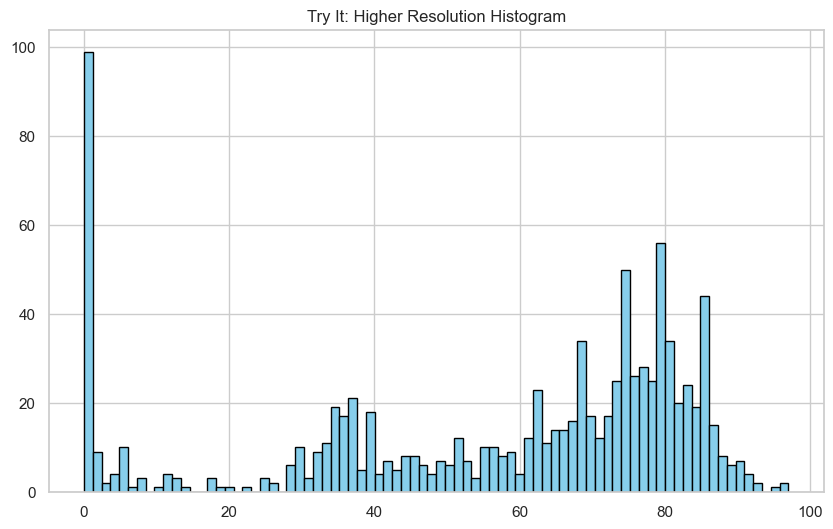

In [18]:
plt.figure(figsize=(10,6))
plt.hist(df['popularity'], bins=80, edgecolor='black', color='skyblue')

plt.title("Try It: Higher Resolution Histogram")
plt.show()

C:\Users\ex012\AppData\Local\Temp\ipykernel_31752\2620223342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data=df, palette='magma')


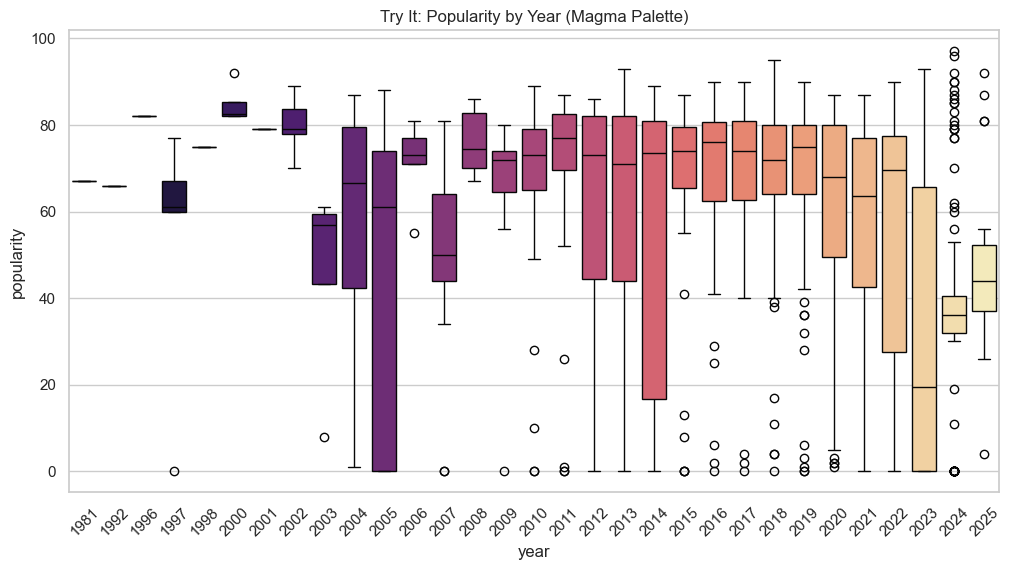

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(x='year', y='popularity', data=df, palette='magma')

plt.title("Try It: Popularity by Year (Magma Palette)")
plt.xticks(rotation=45)

plt.show()

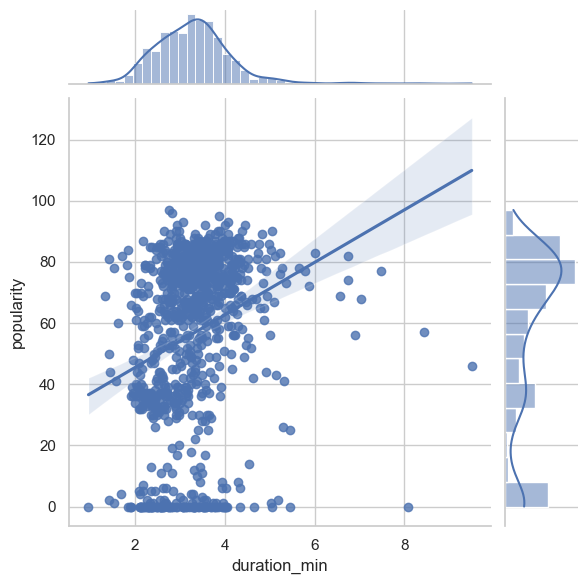

In [20]:
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg'
)

plt.show()

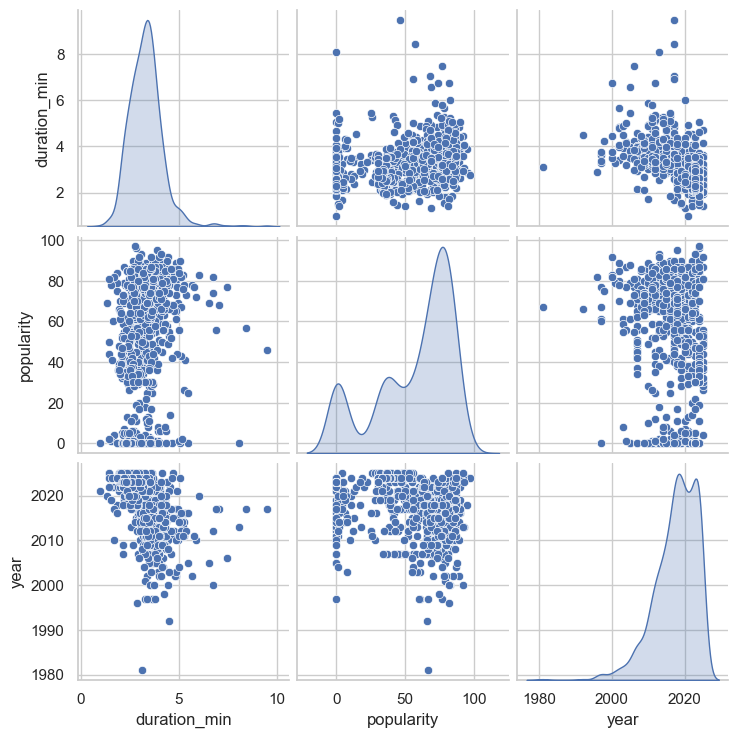

In [21]:
sns.pairplot(df[['duration_min', 'popularity', 'year']].dropna(), diag_kind='kde')
plt.show()

In [39]:
# Top 10 longest tracks (TABLE OUTPUT)
longest = df.nlargest(10, 'duration_min')[['track_name', 'artist', 'duration_min']]

print(longest)

                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

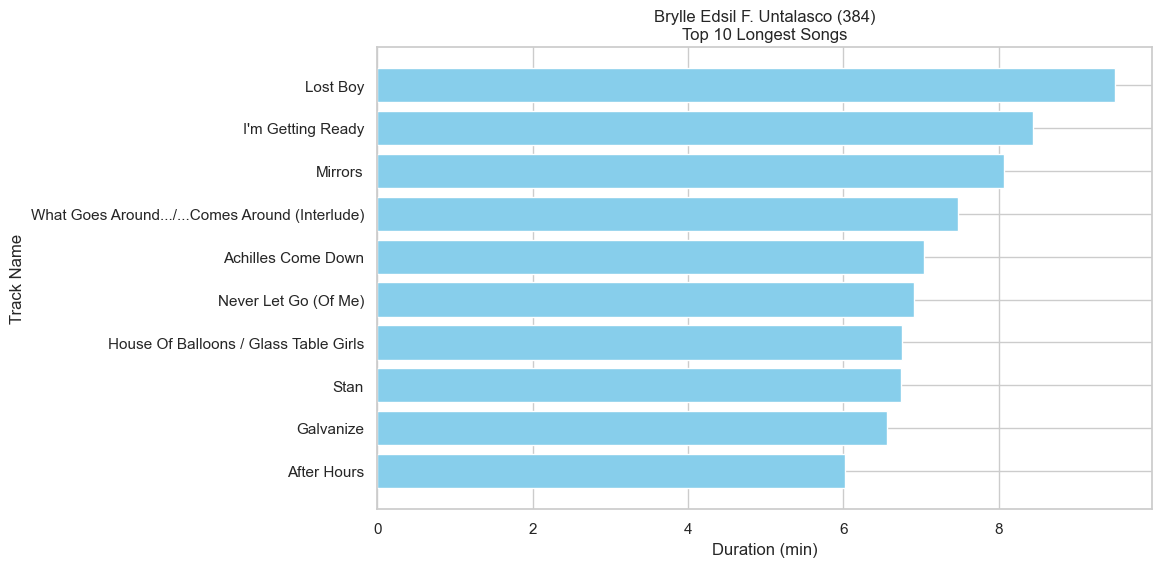

In [40]:
plt.figure(figsize=(10,6))

plt.barh(
    longest['track_name'],
    longest['duration_min'],
    color='skyblue'
)

plt.xlabel("Duration (min)")
plt.ylabel("Track Name")
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs")

plt.gca().invert_yaxis()
plt.show()

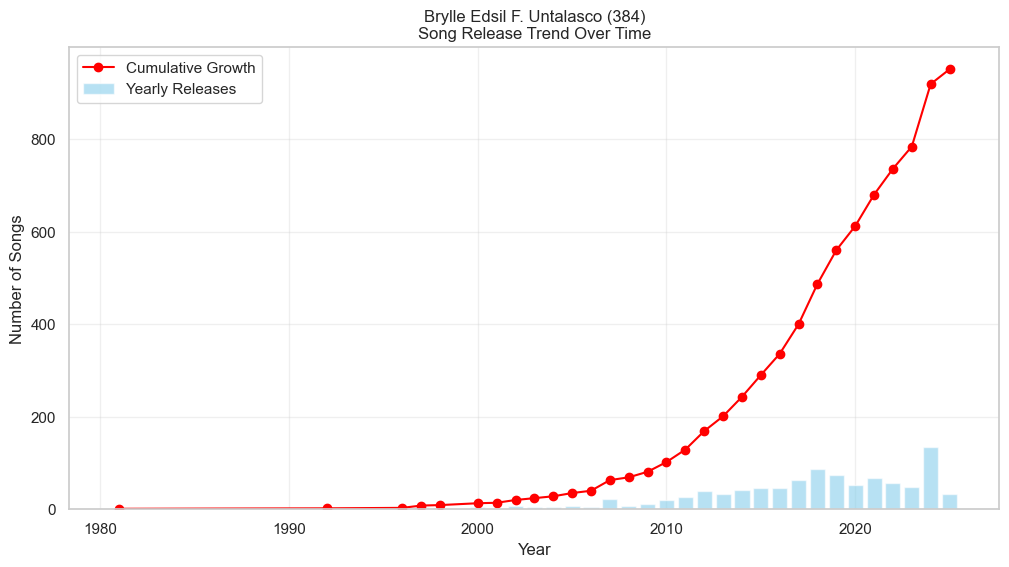

In [41]:
# Yearly counts
yearly_counts = df['year'].value_counts().sort_index()

# Cumulative counts
cumulative_counts = yearly_counts.cumsum()

plt.figure(figsize=(12,6))

# Bar = yearly releases
plt.bar(yearly_counts.index, yearly_counts.values, color='skyblue', alpha=0.6, label='Yearly Releases')

# Line = cumulative
plt.plot(yearly_counts.index, cumulative_counts.values, color='red', marker='o', label='Cumulative Growth')

plt.title(f"{student_name} ({student_id})\nSong Release Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots(figsize=(8,6))

years = sorted(df['year'].dropna().unique())

def update(i):
    ax.clear()
    
    year_data = df[df['year'] <= years[i]]
    
    ax.hexbin(
        year_data['duration_min'],
        year_data['popularity'],
        gridsize=25,
        cmap='coolwarm',
        alpha=0.7
    )
    
    ax.set_title(f"{student_name} ({student_id})\nHexbin Duration vs Popularity (Up to {years[i]})")
    ax.set_xlabel("Duration (min)")
    ax.set_ylabel("Popularity")

ani = FuncAnimation(fig, update, frames=len(years), interval=300)

ani.save("hexbin_animation.gif", writer=PillowWriter(fps=5))

plt.show()

print("Hexbin animation saved!")